# Naive Bayes Classification

## Overview
Naive Bayes is a probabilistic classifier based on **Bayes' Theorem**, with the "naive" assumption that all features are **conditionally independent** given the class label.

### Bayes' Theorem:
$$P(y \mid x_1, \dots, x_n) = \frac{P(y) \prod_{i=1}^{n} P(x_i \mid y)}{P(x_1, \dots, x_n)}$$

Since the denominator is constant across classes, the prediction rule becomes:
$$\hat{y} = \arg\max_{y} \; P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

### Three Common Variants:
| Variant | Use Case | Feature Distribution Assumed |
|---------|----------|------------------------------|
| **GaussianNB** | Continuous features | Normal (Gaussian) |
| **MultinomialNB** | Word counts, text data | Multinomial |
| **BernoulliNB** | Binary features (0/1) | Bernoulli |

---
### Topics Covered
1. Bayes' Theorem intuition
2. Gaussian Naive Bayes — continuous features
3. Decision boundary visualization
4. Model evaluation
5. Multinomial Naive Bayes — text classification
6. Bernoulli Naive Bayes — binary features
7. Comparing all three variants
8. Laplace Smoothing effect
9. Real-world offline-safe dataset (spam detection)
10. Feature log-probabilities


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import StandardScaler, Binarizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification, make_blobs

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Bayes' Theorem — Intuition with a Simple Example

Email contains the word "free" — is it spam?
  Prior P(spam)              = 0.3
  Likelihood P("free"|spam)  = 0.8
  Evidence P("free")         = 0.3100
  Posterior P(spam|"free")   = 0.7742

  -> After seeing "free", spam probability jumped from 30% to 77%!


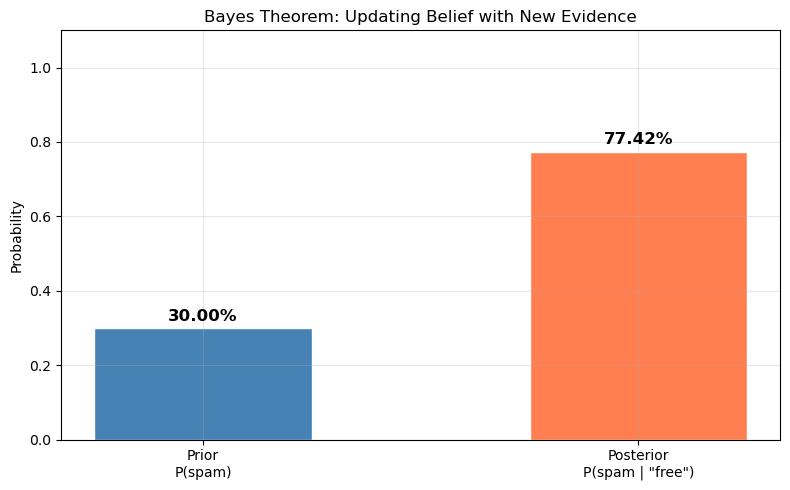

In [2]:
# Classic example: Email spam detection (toy numbers)
P_spam      = 0.30           # Prior: P(spam)
P_not_spam  = 0.70           # Prior: P(not spam)
P_word_given_spam     = 0.80  # P('free' | spam)
P_word_given_not_spam = 0.10  # P('free' | not spam)

# Evidence: P(word='free')
P_word = (P_word_given_spam * P_spam) + (P_word_given_not_spam * P_not_spam)

# Posterior via Bayes Theorem
P_spam_given_word = (P_word_given_spam * P_spam) / P_word

print('Email contains the word "free" — is it spam?')
print(f'  Prior P(spam)              = {P_spam}')
print(f'  Likelihood P("free"|spam)  = {P_word_given_spam}')
print(f'  Evidence P("free")         = {P_word:.4f}')
print(f'  Posterior P(spam|"free")   = {P_spam_given_word:.4f}')
print()
print(f'  -> After seeing "free", spam probability jumped from {P_spam:.0%} to {P_spam_given_word:.0%}!')

# Visualize prior vs posterior
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Prior\nP(spam)', 'Posterior\nP(spam | "free")']
values = [P_spam, P_spam_given_word]
colors = ['steelblue', 'coral']
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.2%}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Probability')
ax.set_title('Bayes Theorem: Updating Belief with New Evidence')
plt.tight_layout()
plt.show()

## 3. Gaussian Naive Bayes — Continuous Features

Class priors    : [0.4975 0.5025]
Feature means    (per class):
[[ 1.52309695 -1.54271318]
 [ 1.56519785  1.52068984]]
Feature variance (per class):
[[0.77871339 1.7016811 ]
 [0.84385254 0.40057018]]

Test Accuracy   : 0.9700


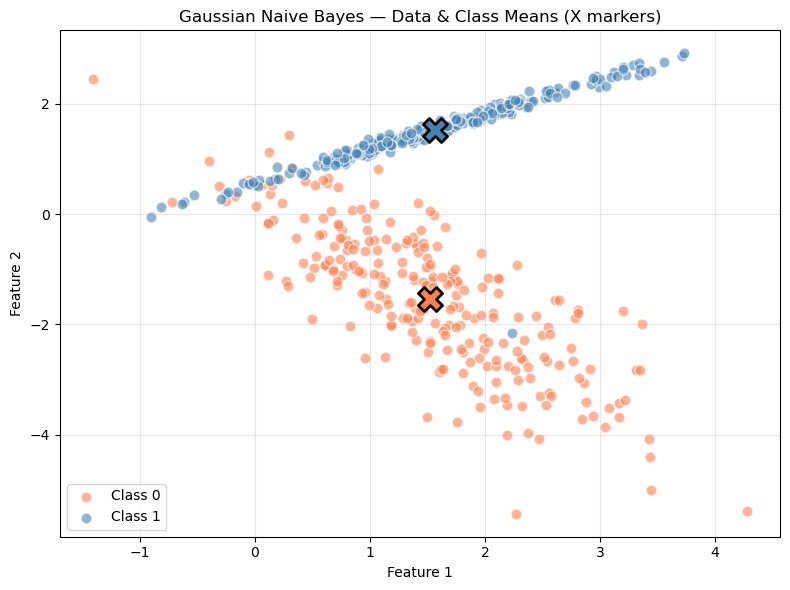

In [3]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)[:, 1]

print(f'Class priors    : {gnb.class_prior_}')
print(f'Feature means    (per class):\n{gnb.theta_}')
print(f'Feature variance (per class):\n{gnb.var_}')
print(f'\nTest Accuracy   : {accuracy_score(y_test, y_pred):.4f}')

# Visualize raw data with Gaussian contours per class
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.6, color='coral',
            edgecolors='white', s=60, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.6, color='steelblue',
            edgecolors='white', s=60, label='Class 1')
for cls, color in zip([0, 1], ['coral', 'steelblue']):
    mean = gnb.theta_[cls]
    plt.scatter(*mean, marker='X', s=300, color=color,
                edgecolors='black', linewidths=2, zorder=5)
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Gaussian Naive Bayes — Data & Class Means (X markers)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Decision Boundary Visualization

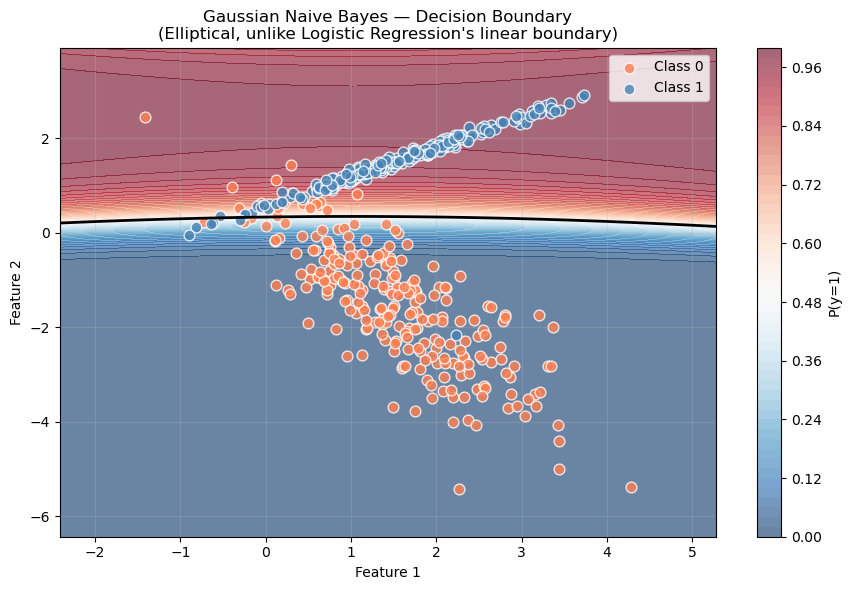

Note: GaussianNB boundaries can be curved/elliptical because each
feature has its own per-class variance (unlike a shared covariance).


In [4]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = gnb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], color='coral', edgecolors='white',
            s=60, alpha=0.8, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='steelblue', edgecolors='white',
            s=60, alpha=0.8, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Gaussian Naive Bayes — Decision Boundary\n(Elliptical, unlike Logistic Regression\'s linear boundary)')
plt.legend()
plt.tight_layout()
plt.show()

print('Note: GaussianNB boundaries can be curved/elliptical because each')
print('feature has its own per-class variance (unlike a shared covariance).')

## 5. Model Evaluation

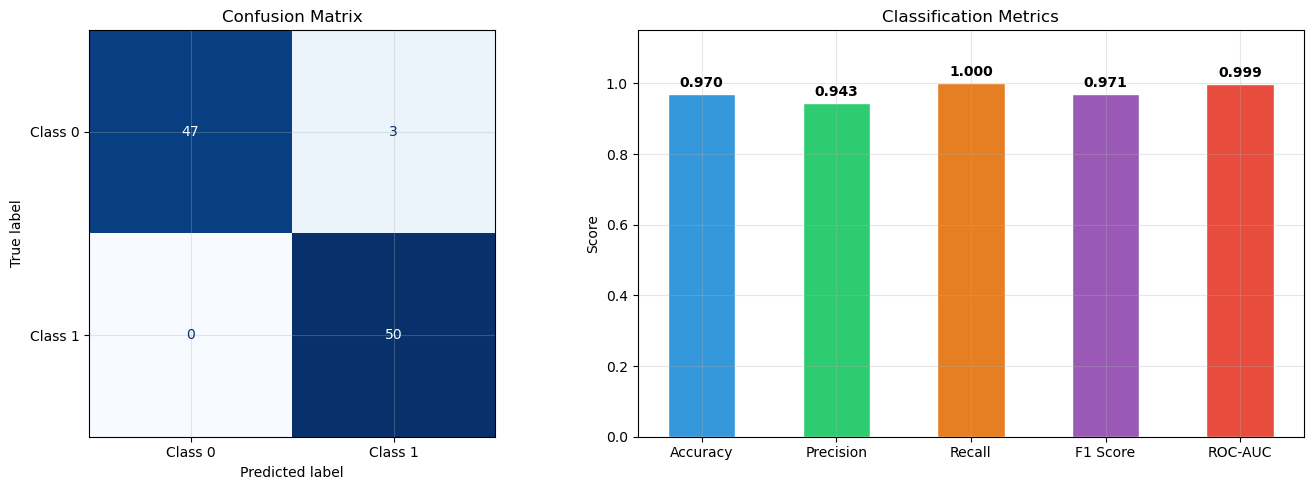


Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.94      0.97        50
     Class 1       0.94      1.00      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1 Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_prob),
}
colors_m = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']
bars = axes[1].bar(metrics.keys(), metrics.values(), color=colors_m,
                   edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Class 0','Class 1']))

## 6. Multinomial Naive Bayes — Text Classification

MultinomialNB is the standard choice for **text data** represented as word counts or TF-IDF scores.

In [6]:
# Synthetic, offline-safe "text" dataset — no downloads needed
sports_docs = [
    'the team won the championship game last night',
    'striker scored a goal in the final minute',
    'the coach praised the defense after the match',
    'fans cheered as the team lifted the trophy',
    'the player broke the scoring record this season',
    'the referee gave a penalty kick in the second half',
    'the league announced the new season schedule',
    'the goalkeeper made an incredible save to win',
    'training camp begins before the tournament starts',
    'the captain led the team to a thrilling victory',
] * 5

tech_docs = [
    'the new smartphone features a faster processor',
    'developers released an update to fix software bugs',
    'the startup raised funding for its AI platform',
    'engineers built a faster algorithm for the database',
    'the company launched a new laptop with better battery',
    'researchers trained a neural network on large datasets',
    'the app update improves performance and security',
    'cloud computing reduces the cost of running servers',
    'the device uses machine learning to detect anomalies',
    'programmers debugged the code before the release',
] * 5

docs   = sports_docs + tech_docs
labels = [0]*len(sports_docs) + [1]*len(tech_docs)   # 0=sports 1=tech

docs_train, docs_test, y_txt_train, y_txt_test = train_test_split(
    docs, labels, test_size=0.25, random_state=42, stratify=labels
)

vectorizer  = CountVectorizer(stop_words='english')
X_txt_train = vectorizer.fit_transform(docs_train)
X_txt_test  = vectorizer.transform(docs_test)

print(f'Vocabulary size : {len(vectorizer.vocabulary_)}')
print(f'Train documents : {len(docs_train)}')
print(f'Test documents  : {len(docs_test)}')
print(f'Sample words    : {list(vectorizer.vocabulary_.keys())[:10]}')

Vocabulary size : 96
Train documents : 75
Test documents  : 25
Sample words    : ['developers', 'released', 'update', 'fix', 'software', 'bugs', 'referee', 'gave', 'penalty', 'kick']


In [7]:
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_txt_train, y_txt_train)

y_txt_pred = mnb.predict(X_txt_test)
y_txt_prob = mnb.predict_proba(X_txt_test)[:, 1]

print(f'Test Accuracy : {accuracy_score(y_txt_test, y_txt_pred):.4f}')
print(f'Test F1 Score : {f1_score(y_txt_test, y_txt_pred):.4f}')
print()
print(classification_report(y_txt_test, y_txt_pred, target_names=['Sports','Tech']))

# Try it on a brand-new sentence
new_sentences = [
    'the team scored a late goal to win the match',
    'the new chip improves smartphone battery life',
    'researchers built a model to predict the score'
]
new_X = vectorizer.transform(new_sentences)
new_pred  = mnb.predict(new_X)
new_prob  = mnb.predict_proba(new_X)

print('\n--- Predictions on new sentences ---')
for sent, pred, prob in zip(new_sentences, new_pred, new_prob):
    label = 'Sports' if pred == 0 else 'Tech'
    print(f'"{sent}"')
    print(f'  -> Predicted: {label}  (P(sports)={prob[0]:.3f}, P(tech)={prob[1]:.3f})\n')

Test Accuracy : 1.0000
Test F1 Score : 1.0000

              precision    recall  f1-score   support

      Sports       1.00      1.00      1.00        13
        Tech       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25


--- Predictions on new sentences ---
"the team scored a late goal to win the match"
  -> Predicted: Sports  (P(sports)=1.000, P(tech)=0.000)

"the new chip improves smartphone battery life"
  -> Predicted: Tech  (P(sports)=0.009, P(tech)=0.991)

"researchers built a model to predict the score"
  -> Predicted: Tech  (P(sports)=0.071, P(tech)=0.929)



## 7. Most Informative Words per Class

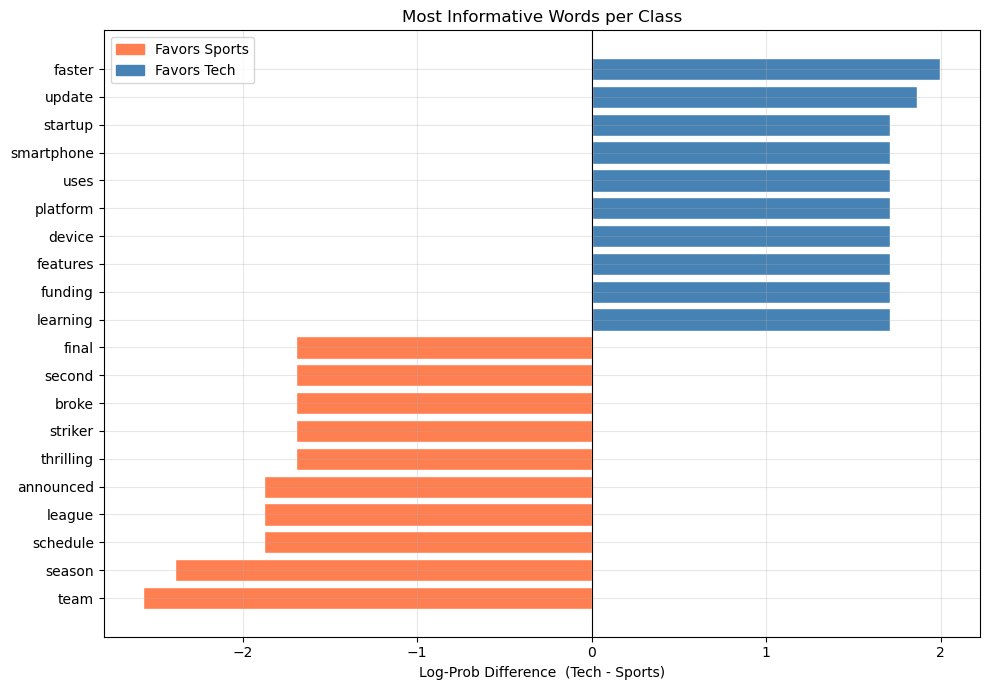

In [8]:
feature_names_txt = vectorizer.get_feature_names_out()
log_probs = mnb.feature_log_prob_   # shape: (n_classes, n_features)

# Difference in log-prob shows which words favor which class
diff = log_probs[1] - log_probs[0]   # positive -> favors Tech, negative -> favors Sports

top_n = 10
top_sports_idx = np.argsort(diff)[:top_n]
top_tech_idx   = np.argsort(diff)[-top_n:]

fig, ax = plt.subplots(figsize=(10, 7))
words   = list(feature_names_txt[top_sports_idx]) + list(feature_names_txt[top_tech_idx])
scores  = list(diff[top_sports_idx]) + list(diff[top_tech_idx])
colors  = ['coral']*top_n + ['steelblue']*top_n

ax.barh(words, scores, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Log-Prob Difference  (Tech - Sports)')
ax.set_title('Most Informative Words per Class')
ax.legend(handles=[
    mpatches.Patch(color='coral',     label='Favors Sports'),
    mpatches.Patch(color='steelblue', label='Favors Tech')
])
plt.tight_layout()
plt.show()

## 8. Bernoulli Naive Bayes — Binary Features

In [9]:
# BernoulliNB cares about presence/absence of a word, not counts
bnb_vectorizer = CountVectorizer(stop_words='english', binary=True)
X_bin_train    = bnb_vectorizer.fit_transform(docs_train)
X_bin_test     = bnb_vectorizer.transform(docs_test)

bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_bin_train, y_txt_train)

y_bin_pred = bnb.predict(X_bin_test)

print(f'BernoulliNB Test Accuracy : {accuracy_score(y_txt_test, y_bin_pred):.4f}')
print(f'BernoulliNB Test F1       : {f1_score(y_txt_test, y_bin_pred):.4f}')

# Compare predictions side-by-side
comparison = pd.DataFrame({
    'Document':       [d[:40]+'...' for d in docs_test[:8]],
    'True Label':      ['Sports' if l==0 else 'Tech' for l in y_txt_test[:8]],
    'Multinomial Pred':['Sports' if p==0 else 'Tech' for p in y_txt_pred[:8]],
    'Bernoulli Pred':  ['Sports' if p==0 else 'Tech' for p in y_bin_pred[:8]],
})
print('\nSample Predictions:')
print(comparison.to_string(index=False))

BernoulliNB Test Accuracy : 1.0000
BernoulliNB Test F1       : 1.0000

Sample Predictions:
                                   Document True Label Multinomial Pred Bernoulli Pred
researchers trained a neural network on ...       Tech             Tech           Tech
engineers built a faster algorithm for t...       Tech             Tech           Tech
the app update improves performance and ...       Tech             Tech           Tech
the referee gave a penalty kick in the s...     Sports           Sports         Sports
engineers built a faster algorithm for t...       Tech             Tech           Tech
the company launched a new laptop with b...       Tech             Tech           Tech
striker scored a goal in the final minut...     Sports           Sports         Sports
the app update improves performance and ...       Tech             Tech           Tech


## 9. Comparing All Three Naive Bayes Variants

=== Naive Bayes Variants Comparison (same underlying data) ===
        Model  Accuracy  F1 Score  ROC-AUC
   GaussianNB    0.9083    0.9091   0.9706
MultinomialNB    0.5750    0.5641   0.6036
  BernoulliNB    0.8750    0.8696   0.9350


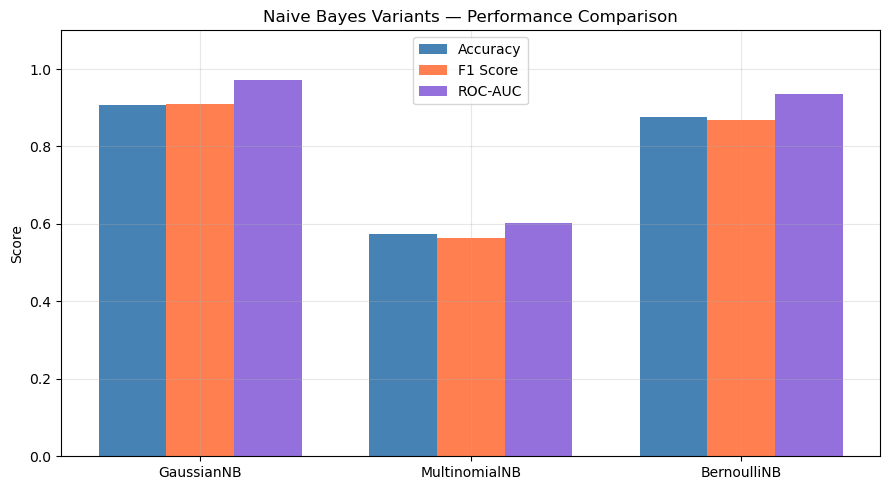


Note: each variant assumes a different feature distribution.
Pick the variant matching your data type for best results:
  Continuous features      -> GaussianNB
  Word counts / frequencies-> MultinomialNB
  Binary / presence-absence-> BernoulliNB


In [10]:
# Numeric dataset for GaussianNB comparison (binarized for BernoulliNB)
np.random.seed(1)
X_cmp, y_cmp = make_classification(
    n_samples=600, n_features=10, n_informative=6,
    n_redundant=2, random_state=1
)
X_cmp_tr, X_cmp_te, y_cmp_tr, y_cmp_te = train_test_split(
    X_cmp, y_cmp, test_size=0.2, random_state=42, stratify=y_cmp
)

# Scale to [0, inf) for MultinomialNB (requires non-negative input)
scaler_pos      = StandardScaler(with_mean=False)
X_cmp_tr_pos    = np.abs(scaler_pos.fit_transform(X_cmp_tr))
X_cmp_te_pos    = np.abs(scaler_pos.transform(X_cmp_te))

# Binarize for BernoulliNB (above/below median)
binarizer       = Binarizer(threshold=0.0)
X_cmp_tr_bin    = binarizer.fit_transform(X_cmp_tr)
X_cmp_te_bin    = binarizer.transform(X_cmp_te)

variants = {
    'GaussianNB':    (GaussianNB(),    X_cmp_tr,     X_cmp_te),
    'MultinomialNB': (MultinomialNB(), X_cmp_tr_pos, X_cmp_te_pos),
    'BernoulliNB':   (BernoulliNB(),   X_cmp_tr_bin, X_cmp_te_bin),
}

rows = []
for name, (model, X_tr, X_te) in variants.items():
    model.fit(X_tr, y_cmp_tr)
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    rows.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_cmp_te, preds), 4),
        'F1 Score': round(f1_score(y_cmp_te, preds), 4),
        'ROC-AUC':  round(roc_auc_score(y_cmp_te, probs), 4),
    })

cmp_df = pd.DataFrame(rows)
print('=== Naive Bayes Variants Comparison (same underlying data) ===')
print(cmp_df.to_string(index=False))

plt.figure(figsize=(9, 5))
x_pos = np.arange(len(cmp_df))
width = 0.25
plt.bar(x_pos - width, cmp_df['Accuracy'], width, label='Accuracy', color='steelblue')
plt.bar(x_pos,         cmp_df['F1 Score'], width, label='F1 Score', color='coral')
plt.bar(x_pos + width,  cmp_df['ROC-AUC'], width, label='ROC-AUC',  color='mediumpurple')
plt.xticks(x_pos, cmp_df['Model'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Naive Bayes Variants — Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print('\nNote: each variant assumes a different feature distribution.')
print('Pick the variant matching your data type for best results:')
print('  Continuous features      -> GaussianNB')
print('  Word counts / frequencies-> MultinomialNB')
print('  Binary / presence-absence-> BernoulliNB')

## 10. Laplace Smoothing — The Alpha Parameter

Without smoothing, a word never seen in training for a class gets probability **zero**, which would zero out the entire product. Laplace (additive) smoothing fixes this.

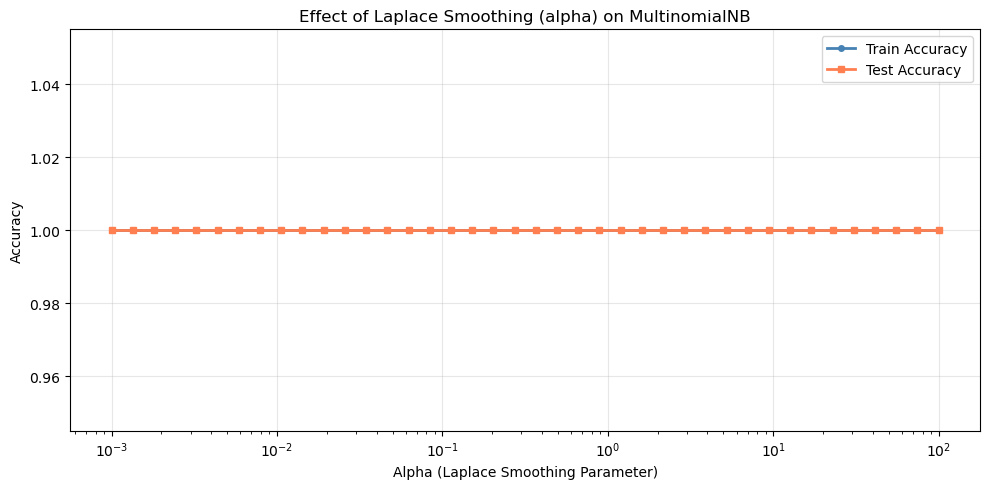

alpha=0     -> No smoothing, unseen words get probability 0 (risky)
alpha=1     -> Standard Laplace smoothing (sklearn default)
Large alpha -> Heavy smoothing, probabilities pulled toward uniform

Unseen-word sentence: "quantum blockchain encryption vortex"
  Prediction: Tech
  P(sports)=0.4933, P(tech)=0.5067
  -> Thanks to smoothing, prediction falls back to the class prior, not zero!


In [11]:
alphas       = np.logspace(-3, 2, 40)
train_accs_s = []
test_accs_s  = []

for a in alphas:
    m = MultinomialNB(alpha=a)
    m.fit(X_txt_train, y_txt_train)
    train_accs_s.append(accuracy_score(y_txt_train, m.predict(X_txt_train)))
    test_accs_s.append( accuracy_score(y_txt_test,  m.predict(X_txt_test)))

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_accs_s, 'o-', color='steelblue', linewidth=2,
             markersize=4, label='Train Accuracy')
plt.semilogx(alphas, test_accs_s,  's-', color='coral',     linewidth=2,
             markersize=4, label='Test Accuracy')
plt.xlabel('Alpha (Laplace Smoothing Parameter)')
plt.ylabel('Accuracy')
plt.title('Effect of Laplace Smoothing (alpha) on MultinomialNB')
plt.legend()
plt.tight_layout()
plt.show()

print('alpha=0     -> No smoothing, unseen words get probability 0 (risky)')
print('alpha=1     -> Standard Laplace smoothing (sklearn default)')
print('Large alpha -> Heavy smoothing, probabilities pulled toward uniform')

# Demonstrate the zero-probability problem directly
rare_sentence = ['quantum blockchain encryption vortex']  # words not in training vocab
rare_X = vectorizer.transform(rare_sentence)
rare_pred = mnb.predict(rare_X)
rare_prob = mnb.predict_proba(rare_X)
print(f'\nUnseen-word sentence: "{rare_sentence[0]}"')
print(f'  Prediction: {"Sports" if rare_pred[0]==0 else "Tech"}')
print(f'  P(sports)={rare_prob[0][0]:.4f}, P(tech)={rare_prob[0][1]:.4f}')
print('  -> Thanks to smoothing, prediction falls back to the class prior, not zero!')

## 11. Real-World Offline-Safe Application — Spam Detection

In [12]:
# Offline-safe synthetic spam/ham dataset
spam_msgs = [
    'win a free prize click now to claim your reward',
    'congratulations you have won a free lottery ticket',
    'limited offer buy now and get a free gift',
    'urgent your account needs verification click here now',
    'cheap meds online no prescription needed buy now',
    'you have been selected for a free cash prize',
    'act now to claim your free vacation package',
    'exclusive deal click here to win a free phone',
    'your loan has been approved click to claim cash',
    'free trial click now limited time offer expires soon',
] * 8

ham_msgs = [
    'hey are we still meeting for lunch tomorrow',
    'can you send me the report before the meeting',
    'happy birthday hope you have a wonderful day',
    'lets catch up this weekend over coffee',
    'the project deadline has been moved to friday',
    'thanks for your help with the presentation yesterday',
    'remember to bring your laptop for the workshop',
    'i will call you after the meeting ends',
    'the package arrived today thanks for ordering it',
    'see you at the conference next week',
] * 8

messages    = spam_msgs + ham_msgs
spam_labels = [1]*len(spam_msgs) + [0]*len(ham_msgs)   # 1=spam 0=ham

msg_train, msg_test, sp_y_train, sp_y_test = train_test_split(
    messages, spam_labels, test_size=0.25, random_state=42, stratify=spam_labels
)

spam_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', MultinomialNB(alpha=0.5))
])
spam_pipe.fit(msg_train, sp_y_train)

sp_pred = spam_pipe.predict(msg_test)
sp_prob = spam_pipe.predict_proba(msg_test)[:, 1]

print(f'Test Accuracy : {accuracy_score(sp_y_test, sp_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(sp_y_test, sp_prob):.4f}')
print()
print(classification_report(sp_y_test, sp_pred, target_names=['Ham','Spam']))

# Cross-validation
cv_scores = cross_val_score(
    spam_pipe, messages, spam_labels,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

# Test on brand new messages
test_msgs = [
    'free cash prize click now to claim your reward today',
    'hey can we reschedule our meeting to next monday'
]
test_preds = spam_pipe.predict(test_msgs)
test_probs = spam_pipe.predict_proba(test_msgs)
print('\n--- New Message Predictions ---')
for msg, pred, prob in zip(test_msgs, test_preds, test_probs):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'"{msg}"\n  -> {label}  (P(spam)={prob[1]:.3f})\n')

Test Accuracy : 1.0000
Test ROC-AUC  : 1.0000

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00        20
        Spam       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

5-Fold CV Accuracy: 1.0000 +/- 0.0000

--- New Message Predictions ---
"free cash prize click now to claim your reward today"
  -> SPAM  (P(spam)=0.983)

"hey can we reschedule our meeting to next monday"
  -> HAM  (P(spam)=0.030)



## 12. Confusion Matrix & ROC for Spam Detector

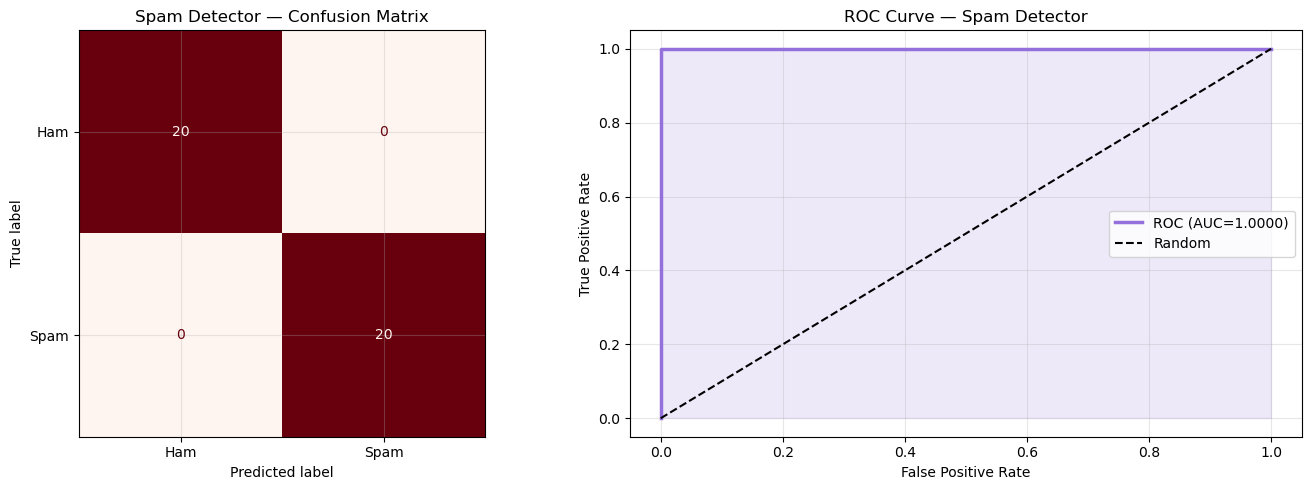

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_spam = confusion_matrix(sp_y_test, sp_pred)
ConfusionMatrixDisplay(cm_spam, display_labels=['Ham','Spam']).plot(
    ax=axes[0], colorbar=False, cmap='Reds'
)
axes[0].set_title('Spam Detector — Confusion Matrix')

fpr, tpr, _ = roc_curve(sp_y_test, sp_prob)
auc_spam    = roc_auc_score(sp_y_test, sp_prob)
axes[1].plot(fpr, tpr, color='mediumpurple', linewidth=2.5,
             label=f'ROC (AUC={auc_spam:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='mediumpurple')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Spam Detector')
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Final Summary & Key Takeaways

In [14]:
print('=' * 65)
print('            NAIVE BAYES - KEY TAKEAWAYS')
print('=' * 65)

takeaways = [
    ('Foundation',        'Based on Bayes Theorem: P(y|x) proportional to P(y)*P(x|y)'),
    ('Naive assumption',  'Features are conditionally independent given the class'),
    ('GaussianNB',        'Best for continuous features (assumes normal distribution)'),
    ('MultinomialNB',     'Best for word counts / frequencies (text classification)'),
    ('BernoulliNB',       'Best for binary features (word present/absent)'),
    ('Alpha (smoothing)', 'Prevents zero-probability for unseen feature values'),
    ('Speed',             'Extremely fast to train and predict, scales to huge data'),
    ('Strength',          'Works surprisingly well even when independence assumption is violated'),
    ('Weakness',          'Cannot capture feature interactions/correlations'),
    ('Use cases',         'Spam filtering, sentiment analysis, document classification'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<18}  ->  {detail}')

print('=' * 65)

            NAIVE BAYES - KEY TAKEAWAYS
  OK  Foundation          ->  Based on Bayes Theorem: P(y|x) proportional to P(y)*P(x|y)
  OK  Naive assumption    ->  Features are conditionally independent given the class
  OK  GaussianNB          ->  Best for continuous features (assumes normal distribution)
  OK  MultinomialNB       ->  Best for word counts / frequencies (text classification)
  OK  BernoulliNB         ->  Best for binary features (word present/absent)
  OK  Alpha (smoothing)   ->  Prevents zero-probability for unseen feature values
  OK  Speed               ->  Extremely fast to train and predict, scales to huge data
  OK  Strength            ->  Works surprisingly well even when independence assumption is violated
  OK  Weakness            ->  Cannot capture feature interactions/correlations
  OK  Use cases           ->  Spam filtering, sentiment analysis, document classification


---
## Practice Exercises

1. **Compare CountVectorizer vs TfidfVectorizer** with MultinomialNB — which performs better and why?
2. **Tune alpha with GridSearchCV** on the spam dataset and find the optimal smoothing value.
3. **Add more spam/ham examples** with different vocabulary and re-evaluate generalization.
4. **Compare against Logistic Regression** on the same text data — which wins on this dataset?
5. **Implement Gaussian Naive Bayes from scratch** using only numpy and the Gaussian PDF formula.
6. **Multiclass text classification** — add a third category (e.g. 'finance') and retrain.

---
*Notebook created for the ML Repository — Naive Bayes module.*